In [177]:
import numpy as np
import pandas as pd
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [152]:
df = pd.read_csv("marketing_campaign.csv",sep='\t')

In [153]:
print(df.shape)
print(df.columns)

(2240, 29)
Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='str')


In [154]:
#Finding Columns having null values
df.columns[df.isnull().any()]

Index(['Income'], dtype='str')

In [155]:
df["Income"].isnull().sum()

np.int64(24)

In [156]:
imputer = KNNImputer(n_neighbors=5)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

print(df['Income'].isnull().sum())

0


In [157]:
print(f"Min Birth Year : {df['Year_Birth'].min()}")
print(f"Max Birth Year : {df['Year_Birth'].max()}")

Min Birth Year : 1893.0
Max Birth Year : 1996.0


In [158]:
df["Age"] = 2026 - df["Year_Birth"]
df["Age"].max()

np.float64(133.0)

In [159]:
df["Education"].unique()    

<StringArray>
['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle']
Length: 5, dtype: str

In [160]:
mappings = {
    'Basic' : 1,
    'Graduation' : 2,
    'Master' : 3,
    '2n Cycle' : 3,  
    'PhD' : 4
}

In [161]:
df["Education"] = df["Education"].map(mappings)
print(df["Education"].value_counts())

Education
2    1127
3     573
4     486
1      54
Name: count, dtype: int64


In [162]:
print(df['Marital_Status'].unique())
print(df["Marital_Status"].value_counts())

<StringArray>
['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone', 'Absurd',
 'YOLO']
Length: 8, dtype: str
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64


In [163]:
marital_grouping = {
    'Married': 'Partner',
    'Together': 'Partner',
    'Single': 'Single',
    'Divorced': 'Single',
    'Widow': 'Single',
    'Alone': 'Single',
    'Absurd': 'Single',
    'YOLO': 'Single'
}
df['Marital_Status'] = df['Marital_Status'].replace(marital_grouping)

bin_map = {
    'Partner': 1,
    'Single': 0
}
df['Marital_Status'] = df['Marital_Status'].map(bin_map)


In [164]:
df["Marital_Status"].value_counts()

Marital_Status
1    1444
0     796
Name: count, dtype: int64

In [165]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')
last_date = df['Dt_Customer'].max()
df['Loyalty_Time'] = (last_date - df['Dt_Customer']).dt.days
df = df.drop(columns=['Dt_Customer'])
print(df[['Loyalty_Time']].head())

   Loyalty_Time
0           663
1           113
2           312
3           139
4           161


In [166]:
df["Z_CostContact"].value_counts()

Z_CostContact
3.0    2240
Name: count, dtype: int64

In [167]:
df["Z_CostContact"].value_counts()

Z_CostContact
3.0    2240
Name: count, dtype: int64

In [168]:
for col in df.columns:
    print(f"{col} : {df[col].value_counts()}")

ID : ID
5524.0     1
2174.0     1
4141.0     1
6182.0     1
5324.0     1
          ..
10870.0    1
4001.0     1
7270.0     1
8235.0     1
9405.0     1
Name: count, Length: 2240, dtype: int64
Year_Birth : Year_Birth
1976.0    89
1971.0    87
1975.0    83
1972.0    79
1970.0    77
1978.0    77
1965.0    74
1973.0    74
1969.0    71
1974.0    69
1956.0    55
1979.0    53
1958.0    53
1952.0    52
1977.0    52
1959.0    51
1968.0    51
1954.0    50
1966.0    50
1955.0    49
1960.0    49
1982.0    45
1963.0    45
1967.0    44
1962.0    44
1957.0    43
1951.0    43
1983.0    42
1986.0    42
1964.0    42
1981.0    39
1980.0    39
1984.0    38
1961.0    36
1953.0    35
1985.0    32
1949.0    30
1989.0    30
1950.0    29
1988.0    29
1987.0    27
1948.0    21
1990.0    18
1946.0    16
1947.0    16
1991.0    15
1992.0    13
1945.0     8
1943.0     7
1944.0     7
1993.0     5
1995.0     5
1994.0     3
1996.0     2
1900.0     1
1893.0     1
1899.0     1
1941.0     1
1940.0     1
Name: count, dtype

In [169]:
cols_to_drop = ['ID', 'Year_Birth', 'Z_CostContact', 'Z_Revenue']
df = df.drop(columns=cols_to_drop)

Outlier Removal process

In [170]:
print("Mean : ",df["Age"].mean())
print("Median : ",df["Age"].median())
print("Std-dev : ",df["Age"].std())
print((df["Age"]>=85).sum())

Mean :  57.19419642857143
Median :  56.0
Std-dev :  11.984069456885829
5


[]

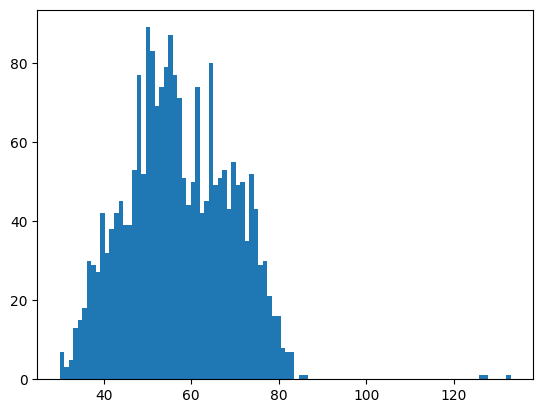

In [171]:
plt.hist(df["Age"],bins=100)
plt.plot()

In [172]:
df = df[df["Age"]<85]

In [173]:
print("Mean : ",df["Income"].mean())
print("Median : ",df["Income"].median())
print("Std-dev : ",df["Income"].std())
print((df["Income"]>=100000).sum())

Mean :  52174.14568232662
Median :  51369.0
Std-dev :  25105.938071418706
13


In [174]:
highest_incomes = df[df['Income'] >= 100000]['Income'].sort_values(ascending=False)
print(highest_incomes)

2233    666666.0
617     162397.0
687     160803.0
1300    157733.0
164     157243.0
1653    157146.0
2132    156924.0
655     153924.0
1898    113734.0
646     105471.0
252     102692.0
203     102160.0
124     101970.0
Name: Income, dtype: float64


[]

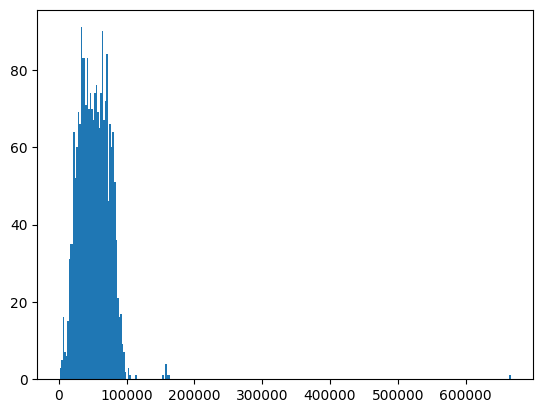

In [175]:
plt.hist(df["Income"],bins=300)
plt.plot()

In [148]:
df = df[df['Income'] < 200000]

In [176]:
df['Total_Spend'] = (df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + 
                     df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds'])

df['Share_Wine'] = df['MntWines'] / (df['Total_Spend'] + 1e-6)
df['Share_Meat'] = df['MntMeatProducts'] / (df['Total_Spend'] + 1e-6)
df['Share_Fish'] = df['MntFishProducts'] / (df['Total_Spend'] + 1e-6)
df['Share_Sweet'] = df['MntSweetProducts'] / (df['Total_Spend'] + 1e-6)
df['Share_Gold'] = df['MntGoldProds'] / (df['Total_Spend'] + 1e-6)
df['Share_Fruit'] = df['MntFruits'] / (df['Total_Spend'] + 1e-6)

df['Total_Purchases'] = (df['NumWebPurchases'] + df['NumCatalogPurchases'] + df['NumStorePurchases'])

df['Share_Web_Purchases'] = df['NumWebPurchases'] / (df['Total_Purchases'] + 1e-6)
df['Share_Catalog_Purchases'] = df['NumCatalogPurchases'] / (df['Total_Purchases'] + 1e-6)
df['Share_Store_Purchases'] = df['NumStorePurchases'] / (df['Total_Purchases'] + 1e-6)

df['Total_Promos_Accepted'] = (df['AcceptedCmp1'] + df['AcceptedCmp2'] + df['AcceptedCmp3'] + 
                               df['AcceptedCmp4'] + df['AcceptedCmp5'] + df['Response'])

cols_to_drop_agg = [
    'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response'
]

df = df.drop(columns=cols_to_drop_agg)

print("Shape : ", df.shape)

Shape :  (2235, 23)


In [178]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)
df_scaled = pd.DataFrame(scaled_data, columns=df.columns)

df_scaled.to_csv('dataset_cleaned.csv', index=False)

print("Final Shape:", df_scaled.shape)

Final Shape: (2235, 23)
